# Phase 2 - Explainability Analysis with Grad-CAM and Grad-CAM++

**Three models we compare (one representative fold each):**
- **ResNet-50** - a pure CNN
- **ViT-Base/16** - a pure Vision Transformer
- **TinyViT-21M** - a CNN+Transformer hybrid

**Two evaluation metrics (kept deliberately small and explainable):**
1. **Inside-body fraction** - how much of the heatmap falls inside the patient's body (higher is better).
2. **Deletion AUC** — whether the highlighted pixels really drive the prediction (lower is better).

In [ ]:

import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

sys.path.insert(0, str(Path.cwd().parent / "src"))


from data import PneumoniaDataset, get_eval_transform, CLASS_NAMES
from xai import load_model, run_cam, get_cam_config, tensor_to_rgb

from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

METHODS = ["gradcam", "gradcam++"]

Device: cuda


## 1 - The three models we explain

We trained each architecture with 5-fold cross-validation, so we actually have 5 saved models (folds) per architecture.

In [ ]:
# Representative fold per architecture (chosen by: test-F1 closest to the mean test-F1).
MODELS = [
    ("resnet50",             "../checkpoints/resnet50_fold4_best.pth",             "ResNet-50 (CNN)"),
    ("vit_base_patch16_384", "../checkpoints/vit_base_patch16_384_fold2_best.pth", "ViT-Base (Transformer)"),
    ("tiny_vit_21m_384",     "../checkpoints/tiny_vit_21m_384_fold0_best.pth",     "TinyViT (Hybrid)"),
]

for name, ckpt, disp in MODELS:
    assert Path(ckpt).exists(), f"Missing checkpoint: {ckpt}"
    print(f"OK  {disp:26s} -> {Path(ckpt).name}")

test_ds = PneumoniaDataset("test", transform=get_eval_transform())
print(f"Test images: {len(test_ds)}")

OK  ResNet-50 (CNN)            -> resnet50_fold4_best.pth
OK  ViT-Base (Transformer)     -> vit_base_patch16_384_fold2_best.pth
OK  TinyViT (Hybrid)           -> tiny_vit_21m_384_fold0_best.pth
Test images: 624


In [ ]:
# Take one test image (shape: batch=1, channels=3, height=384, width=384).
demo_img = test_ds[0][0].unsqueeze(0).to(device)

for name, ckpt, disp in MODELS:
    model = load_model(name, ckpt, device)           
    target_layers, reshape = get_cam_config(model, name)
    cam, pred = run_cam(model, name, demo_img, method="gradcam")
    print(f"{disp:26s} | target={target_layers[0].__class__.__name__:11s} "
          f"| reshape={'yes' if reshape else 'no ':3s} "
          f"| heatmap shape={cam.shape} | predicted={CLASS_NAMES[pred]}")
    del model; torch.cuda.empty_cache()             

ResNet-50 (CNN)            | target=Bottleneck  | reshape=no  | heatmap shape=(384, 384) | predicted=NORMAL
ViT-Base (Transformer)     | target=LayerNorm   | reshape=yes | heatmap shape=(384, 384) | predicted=NORMAL
TinyViT (Hybrid)           | target=ConvNorm    | reshape=no  | heatmap shape=(384, 384) | predicted=NORMAL


## 4 - Qualitative analysis

- **2 images where the three models disagree** (different predictions on the same X-ray)
- **2 correctly-classified PNEUMONIA** images
- **2 correctly-classified NORMAL** images


Chosen image indices: [47, 52, 472, 579, 73, 153]


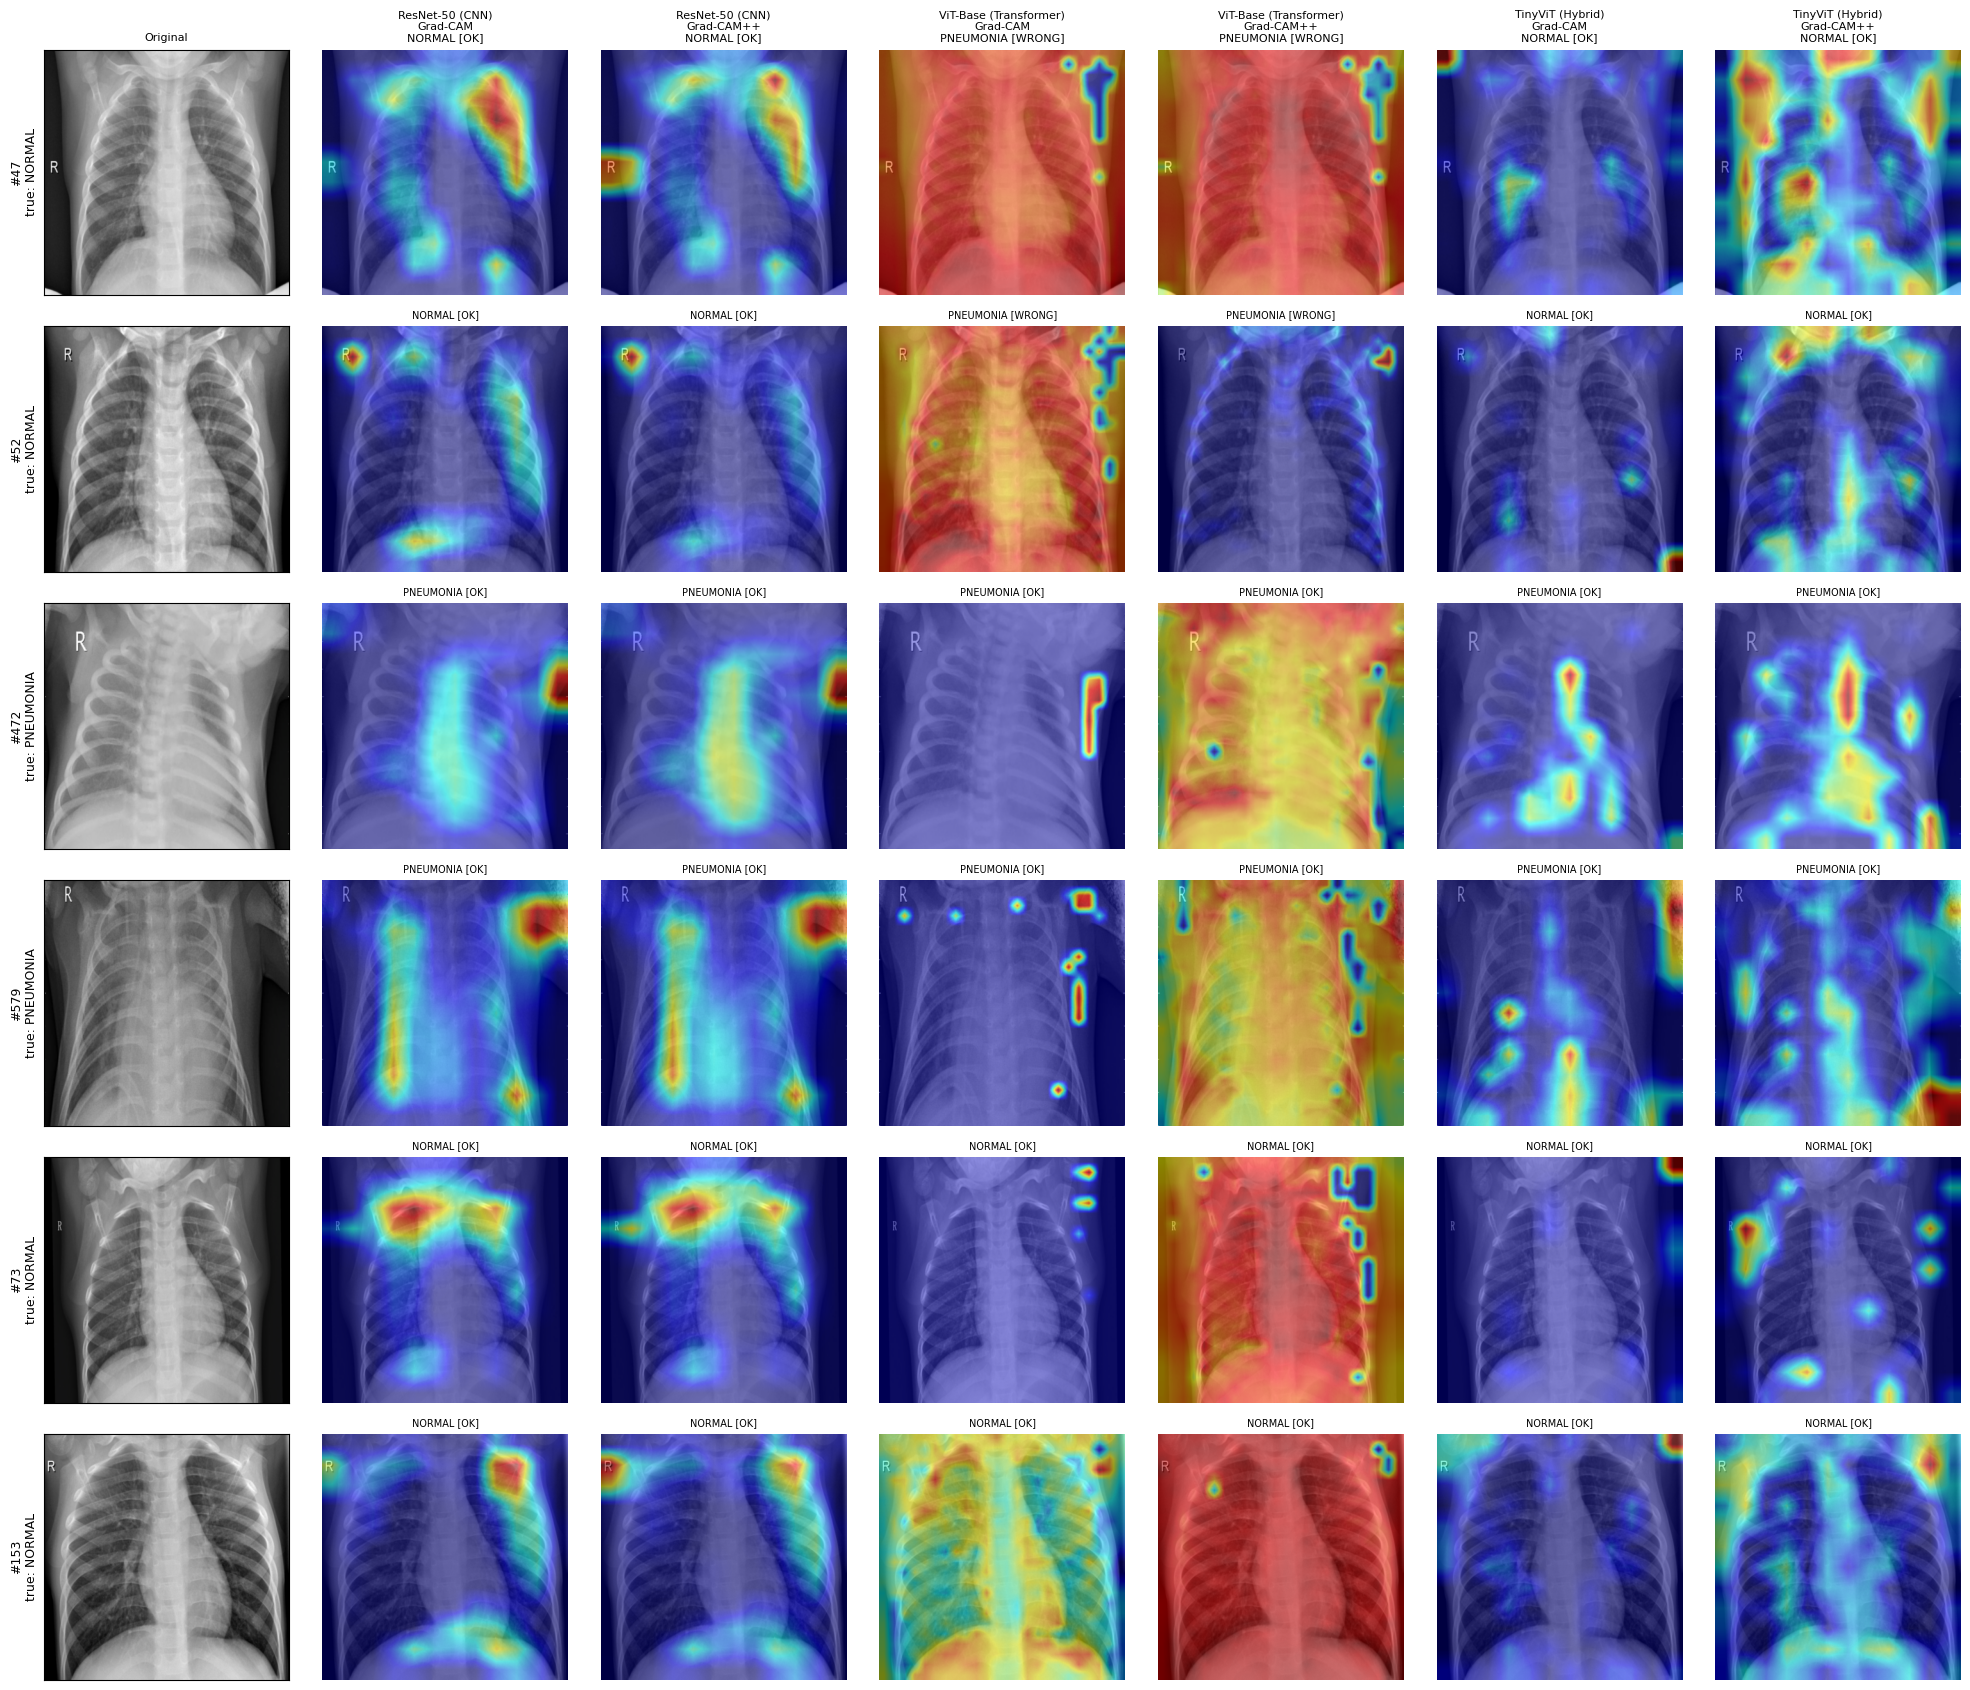

Saved ../results/phase2_grid_report_6.png


In [ ]:
# Load the frozen qualitative list (15 images) and the predictions are recomputed below.
with open("../results/phase2_image_sets.json") as f:
    qual_set = json.load(f)["qualitative"]

preds = {}
for name, ckpt, disp in MODELS:
    model = load_model(name, ckpt, device)
    for i, it in enumerate(qual_set):
        x = test_ds[it["index"]][0].unsqueeze(0).to(device)
        with torch.no_grad():
            preds[(i, name)] = model(x).argmax(1).item()
    del model; torch.cuda.empty_cache()


disagree, corr_pneu, corr_norm = [], [], []
for i, it in enumerate(qual_set):
    p = [preds[(i, n)] for n, _, _ in MODELS]
    all_correct = all(v == it["true_label"] for v in p)
    if len(set(p)) > 1:                          disagree.append(i)   
    elif all_correct and it["true_label"] == 1:  corr_pneu.append(i)  
    elif all_correct and it["true_label"] == 0:  corr_norm.append(i) 
chosen = disagree[:2] + corr_pneu[:2] + corr_norm[:2]
for i in range(len(qual_set)):                   
    if len(chosen) == 6: break
    if i not in chosen: chosen.append(i)
chosen = chosen[:6]
print("Chosen image indices:", [qual_set[i]["index"] for i in chosen])

items   = [qual_set[i] for i in chosen]
tensors = [test_ds[it["index"]][0] for it in items]
rgbs    = [tensor_to_rgb(t) for t in tensors]      

heat, plabel = {}, {}
for name, ckpt, disp in MODELS:
    model = load_model(name, ckpt, device)
    for r, t in enumerate(tensors):
        x = t.unsqueeze(0).to(device)
        for m in METHODS:
            cam, pred = run_cam(model, name, x, method=m)
            heat[(r, name, m)] = cam
            plabel[(r, name)]  = pred
    del model; torch.cuda.empty_cache()

col_titles = ["Original"]
for _, _, disp in MODELS:
    col_titles += [f"{disp}\nGrad-CAM", f"{disp}\nGrad-CAM++"]

fig, ax = plt.subplots(6, 7, figsize=(20, 17))
for r, it in enumerate(items):
    true = CLASS_NAMES[it["true_label"]]
    ax[r][0].imshow(rgbs[r]); ax[r][0].set_xticks([]); ax[r][0].set_yticks([])
    ax[r][0].set_ylabel(f"#{it['index']}\ntrue: {true}", fontsize=9)
    c = 1
    for name, _, disp in MODELS:
        pred = CLASS_NAMES[plabel[(r, name)]]
        tag = "OK" if pred == true else "WRONG"
        for m in METHODS:
            ax[r][c].imshow(show_cam_on_image(rgbs[r], heat[(r, name, m)], use_rgb=True))
            ax[r][c].set_title(f"{pred} [{tag}]", fontsize=7); ax[r][c].axis("off")
            c += 1
for c in range(7):
    ax[0][c].set_title(col_titles[c] + ("" if c == 0 else f"\n{ax[0][c].get_title()}"), fontsize=8)

plt.tight_layout()
plt.savefig("../results/phase2_grid_report_6.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved ../results/phase2_grid_report_6.png")

## 5 - Evaluation Metric 1: Inside-body fraction

**Question it answers:** does the heatmap stay *inside the patient's body*, or does it leak onto the background, the borders, or the "R" marker?

In [ ]:
from scipy import ndimage  

def body_mask(rgb_img):
    """Return a True/False mask of the body region (True = inside body)."""
    gray = rgb_img.mean(axis=2)                       
    mask = gray > (gray.mean() * 0.45)                
    mask = ndimage.binary_fill_holes(mask)           
    mask = ndimage.binary_closing(mask, iterations=3) 
    lbl, n = ndimage.label(mask)                       
    if n > 0:                                          
        sizes = ndimage.sum(mask, lbl, range(1, n + 1))
        mask = lbl == (np.argmax(sizes) + 1)
    return mask

def inside_fraction(cam, mask):
    """Fraction (0..1) of heatmap energy that lies inside the body mask."""
    total = cam.sum()
    return float((cam * mask).sum() / total) if total > 0 else 0.0

with open("../results/phase2_image_sets.json") as f:
    quant_set = json.load(f)["quantitative"]

masks = {it["index"]: body_mask(tensor_to_rgb(test_ds[it["index"]][0])) for it in quant_set}

inside_results = {}
for name, ckpt, disp in MODELS:
    model = load_model(name, ckpt, device)
    inside_results[disp] = {}
    for m in METHODS:
        fracs = []
        for it in quant_set:
            x = test_ds[it["index"]][0].unsqueeze(0).to(device)
            cam, _ = run_cam(model, name, x, method=m)
            fracs.append(inside_fraction(cam, masks[it["index"]]))
        inside_results[disp][m] = float(np.mean(fracs))
    del model; torch.cuda.empty_cache()
    print(f"{disp}: done")

# Print a small results table.
print("\nInside-body fraction (HIGHER = heatmap stays inside the body):")
print(f"{'Model':<26}{'Grad-CAM':>10}{'Grad-CAM++':>12}")
for disp, r in inside_results.items():
    print(f"{disp:<26}{r['gradcam']:>10.3f}{r['gradcam++']:>12.3f}")

ResNet-50 (CNN): done
ViT-Base (Transformer): done
TinyViT (Hybrid): done

Inside-body fraction (HIGHER = heatmap stays inside the body):
Model                       Grad-CAM  Grad-CAM++
ResNet-50 (CNN)                0.925       0.928
ViT-Base (Transformer)         0.775       0.752
TinyViT (Hybrid)               0.829       0.824


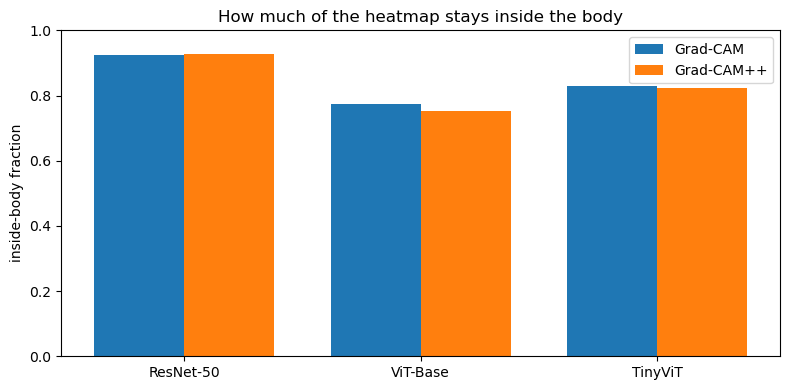

In [ ]:

labels = list(inside_results.keys())
x = np.arange(len(labels)); w = 0.38
plt.figure(figsize=(8, 4))
plt.bar(x - w/2, [inside_results[d]["gradcam"]   for d in labels], w, label="Grad-CAM")
plt.bar(x + w/2, [inside_results[d]["gradcam++"] for d in labels], w, label="Grad-CAM++")
plt.xticks(x, [d.split(" (")[0] for d in labels])
plt.ylabel("inside-body fraction"); plt.ylim(0, 1)
plt.title("How much of the heatmap stays inside the body"); plt.legend()
plt.tight_layout(); plt.savefig("../results/phase2_inside_body_bar.png", dpi=130); plt.show()

## Evaluation Metric 2: Deletion AUC (faithfulness)

**Question it answers:** are the highlighted pixels *really* the ones the model used? A pretty heatmap is not enough, it must be **faithful**.

In [7]:
def softmax_conf(model, x, cls):
    """Model's probability for class `cls` on input image `x`."""
    with torch.no_grad():
        return F.softmax(model(x), dim=1)[0, cls].item()

def deletion_auc(model, name, x, method, steps=50):
    """Average confidence as we delete the most-important pixels first (lower = better)."""
    cam, pred = run_cam(model, name, x, method=method)
    # Pixel indices sorted most-important -> least-important.
    # .copy() avoids a negative-stride error when feeding the reversed array to torch.
    order = np.argsort(cam.ravel())[::-1].copy()
    n_pix = cam.size
    step = max(1, n_pix // steps)
    confs = []
    for s in range(0, n_pix + 1, step):
        work = x.clone()
        work.view(1, 3, -1)[:, :, order[:s]] = 0.0   # zero out the top-s important pixels
        confs.append(softmax_conf(model, work, pred))
    return float(np.mean(confs))

# Balanced 60-image subset (this metric is slow).
rng = np.random.default_rng(42)
normals = [it for it in quant_set if it["true_label"] == 0]
pneus   = [it for it in quant_set if it["true_label"] == 1]
subset  = list(rng.choice(normals, 30, replace=False)) + list(rng.choice(pneus, 30, replace=False))

deletion_results = {}
for name, ckpt, disp in MODELS:
    model = load_model(name, ckpt, device)
    deletion_results[disp] = {}
    for m in METHODS:
        scores = [deletion_auc(model, name,
                               test_ds[it["index"]][0].unsqueeze(0).to(device), m)
                  for it in subset]
        deletion_results[disp][m] = float(np.mean(scores))
    del model; torch.cuda.empty_cache()
    print(f"{disp}: done")

print("\nDeletion AUC (LOWER = more faithful heatmap):")
print(f"{'Model':<26}{'Grad-CAM':>10}{'Grad-CAM++':>12}")
for disp, r in deletion_results.items():
    print(f"{disp:<26}{r['gradcam']:>10.3f}{r['gradcam++']:>12.3f}")

ResNet-50 (CNN): done
ViT-Base (Transformer): done
TinyViT (Hybrid): done

Deletion AUC (LOWER = more faithful heatmap):
Model                       Grad-CAM  Grad-CAM++
ResNet-50 (CNN)                0.532       0.548
ViT-Base (Transformer)         0.794       0.768
TinyViT (Hybrid)               0.621       0.649


In [ ]:
# Save the two metric tables to one file for the report.
summary = {"inside_body_fraction": inside_results, "deletion_auc": deletion_results}
with open("../results/phase2_xai_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved ../results/phase2_xai_summary.json")